In [273]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [274]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'

!wget $data -O homework_03_course_lead_scoring_2026.csv

--2026-10-04 13:14:16--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: ‘homework_03_course_lead_scoring_2026.csv’

homework_03_course_ 100%[===================>] 272.21K  --.-KB/s    in 0.006s  

2026-10-04 13:14:16 (46.7 MB/s) - ‘homework_03_course_lead_scoring_2026.csv’ saved [278746/278746]



In [275]:
df = pd.read_csv('homework_03_course_lead_scoring_2026.csv')

In [276]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [277]:
df.shape

(5000, 9)

In [278]:
df.dtypes

lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [279]:
df.isna().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [280]:
df['interaction_count'].nunique()

14

In [281]:
df['number_of_courses_viewed'].nunique()

7

In [282]:
df.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='str')

In [283]:
numerical = ['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']

In [284]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']

In [286]:
for c in numerical:
    df[c] = df[c].fillna(0.0)

In [293]:
df[numerical].head()

,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,88160.0,3,4,0.64
1,72688.0,3,7,0.72
2,44697.0,3,4,0.58
3,0.0,3,6,0.57
4,24062.0,4,5,0.62


In [294]:
for c in categorical:
    df[c] = df[c].fillna('NA')

In [295]:
df[categorical].head()

,lead_source,industry,employment_status,location
0,organic_search,technology,employed,europe
1,social_media,technology,employed,south_america
2,referral,retail,employed,europe
3,paid_ads,manufacturing,student,NA
4,referral,manufacturing,student,north_america


In [297]:
df['industry'].value_counts()

industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64

In [299]:
mode_industry = df['industry'].mode()[0]
mode_industry

'technology'

In [300]:
df[numerical].corrwith(df.converted)

annual_income               0.189652
number_of_courses_viewed    0.395038
interaction_count           0.448624
lead_score                  0.483246
dtype: float64

In [314]:
correlation_matrix = df[numerical].corr().to_numpy()
correlation_matrix

array([[1.        , 0.16129999, 0.12284235, 0.22949591],
       [0.16129999, 1.        , 0.721609  , 0.75720424],
       [0.12284235, 0.721609  , 1.        , 0.9157458 ],
       [0.22949591, 0.75720424, 0.9157458 , 1.        ]])

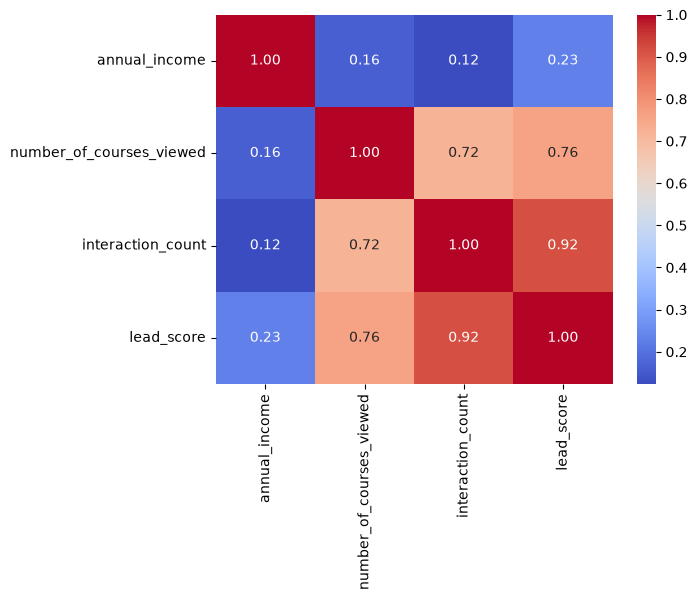

In [302]:
sns.heatmap(df[numerical].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [305]:
# max_corr = -1
# best_pair = None
# for i in range(len(numerical)):
#     for j in range(i + 1, len(numerical)):
#         feat1 = numerical[i]
#         feat2 = numerical[j]
#         corr_val = correlation_matrix.loc[feat1, feat2]
        
#         if corr_val > max_corr:
#             max_corr = corr_val
#             best_pair = (feat1, feat2)

# print(f"Highest correlation pair: {best_pair[0]} & {best_pair[1]} with a correlation of {max_corr:.4f}")

In [317]:
num_indices = {feat: idx for idx, feat in enumerate(numerical)}

pairs = [
    ('interaction_count', 'lead_score'),
    ('number_of_courses_viewed', 'lead_score'),
    ('number_of_courses_viewed', 'interaction_count'),
    ('annual_income', 'interaction_count')
]

max_corr = -1
best_pair = None

for feat1, feat2 in pairs:
    i = num_indices[feat1]
    j = num_indices[feat2]
    
    corr_val = correlation_matrix[i, j]
    
    if corr_val > max_corr:
        max_corr = corr_val
        best_pair = (feat1, feat2)

print(f"Highest correlation among the pairs: {best_pair[0]} & {best_pair[1]} ({max_corr:.4f})")

Highest correlation among the pairs: interaction_count & lead_score (0.9157)


In [318]:
from sklearn.model_selection import train_test_split

In [319]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=42
)

In [321]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_full_train = df_full_train.reset_index(drop=True)

In [322]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values
y_full_train = df_full_train.converted.values


In [323]:
del df_train['converted']
del df_val['converted']
del df_test['converted']
del df_full_train['converted']

In [324]:
from sklearn.metrics import mutual_info_score

In [334]:
def mutual_info_converted_score(series):
    return mutual_info_score(series, y_train)

In [336]:
mi = df_train[categorical].apply(mutual_info_converted_score)
mi.sort_values(ascending=False).round(2)

lead_source          0.03
employment_status    0.02
industry             0.00
location             0.00
dtype: float64

In [342]:
print(f"Biggest MI score: {mi.idxmax()} ({mi[mi.idxmax()]:.2f})")

Biggest MI score: lead_source (0.03)


In [343]:
from sklearn.feature_extraction import DictVectorizer

In [344]:
dv = DictVectorizer(sparse=False)

In [345]:
train_dict = df_train[categorical + numerical].to_dict(orient='records')

In [347]:
dv.fit(train_dict)

DictVectorizer(sparse=False)

In [348]:
X_train = dv.fit_transform(train_dict)

In [350]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [351]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [352]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [353]:
y_pred = model.predict_proba(X_val)[:, 1]

In [354]:
converted_decision = (y_pred >= 0.5)

In [356]:
(y_val == converted_decision).mean().round(2)

np.float64(0.64)

In [362]:
def feature_elimination_scores(df_train, df_val, y_train, y_val, features):
   
    def get_accuracy(train_data, val_data):
        dv = DictVectorizer(sparse=False)
        X_tr = dv.fit_transform(train_data.to_dict(orient='records'))
        X_va = dv.transform(val_data.to_dict(orient='records'))
        
        model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
        model.fit(X_tr, y_train)
        
        y_pred = model.predict_proba(X_va)[:, 1]
        return (y_val == (y_pred >= 0.5)).mean()

    
    original_acc = get_accuracy(df_train[features], df_val[features])
    print(f"Original Accuracy: {original_acc:.6f}\n")
    
    
    diffs = {}
    for feature in features:
        subset_features = [f for f in features if f != feature]
        acc_without = get_accuracy(df_train[subset_features], df_val[subset_features])
        
        
        diffs[feature] = original_acc - acc_without

    diff_series = pd.Series(diffs).sort_values()
    return diff_series

In [363]:
all_features = categorical + numerical

diffs = feature_elimination_scores(df_train, df_val, y_train, y_val, all_features)
print(diffs)

print("\nLeast useful feature:", diffs.idxmin())

Original Accuracy: 0.645000

annual_income              -0.079
industry                    0.000
location                    0.000
employment_status           0.000
lead_score                  0.001
number_of_courses_viewed    0.002
lead_source                 0.003
interaction_count           0.044
dtype: float64

Least useful feature: annual_income


In [364]:
candidate_features = ['lead_source', 'number_of_courses_viewed', 'interaction_count']
filtered_diffs = diffs[candidate_features]

In [365]:
smallest_feature = filtered_diffs.idxmin()
print(f"Feature with smallest difference: {smallest_feature} ({filtered_diffs[smallest_feature]:.3f})")

Feature with smallest difference: number_of_courses_viewed (0.002)


In [366]:
def tune_c_parameters(df_train, df_val, y_train, y_val, features, c_values):
    
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(df_train[features].to_dict(orient='records'))
    X_val = dv.transform(df_val[features].to_dict(orient='records'))
    
    results = {}
    
    for c in c_values:
        model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        
        y_pred = model.predict_proba(X_val)[:, 1]
        acc = (y_val == (y_pred >= 0.5)).mean()
        
        results[c] = round(acc, 3)
        print(f"C={c:<8} -> Validation Accuracy: {round(acc, 3):.3f}")
        
    return results

In [368]:
c_values = [0.000001, 0.00001, 0.0001, 0.001]
all_features = categorical + numerical

scores = tune_c_parameters(df_train, df_val, y_train, y_val, all_features, c_values)

# Find the C value with the highest accuracy
best_c = max(scores, key=scores.get)

print(f"\nThe C value that leads to the best accuracy is C={best_c} with an accuracy of {scores[best_c]:.3f}")

C=1e-06    -> Validation Accuracy: 0.598
C=1e-05    -> Validation Accuracy: 0.598
C=0.0001   -> Validation Accuracy: 0.613
C=0.001    -> Validation Accuracy: 0.645

The C value that leads to the best accuracy is C=0.001 with an accuracy of 0.645
